# Chapter 21: Quotient Manifolds

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `540-563`.
The working extraction window was `pdftotext -f 558 -l 581`, with smaller
checks around the theorem proof, covering-space section, homogeneous-space
section, Lie-theory applications, and problem list.

**Chapter goal.** Learn when an orbit space of a smooth Lie group action is
actually a smooth manifold, why freeness and properness are the two hypotheses
that make the theorem work, and how the same quotient mechanism produces
covering manifolds, homogeneous spaces, quotient Lie groups, and connectedness
results for familiar matrix groups.

The notebook is self-contained: it uses the source only as a map of the chapter's
topics, and then builds original diagrams, computations, and checks.


## Refreshed Visual Storyboard

1. **Hypothesis traffic.** A dependency graph tracks how orbit spaces, open
quotient maps, properness, embedded orbits, adapted charts, and submersion
coordinates feed the quotient manifold theorem.
2. **Good and bad orbit spaces.** A gallery compares translation quotients,
rotation quotients with fixed points, two-orbit non-Hausdorff quotients, and
discrete translation quotients.
3. **Properness diagnostics.** Compact-window tests and convergent-sequence
tests are made numerical for translations, dilations, and irrational torus flows.
4. **Adapted charts.** A local coordinate picture shows the theorem's proof
move: group directions become fiber coordinates and transverse slice coordinates
become quotient coordinates.
5. **Discrete actions as coverings.** Lattice translations of the plane show how
local sheets of a quotient map become evenly covered neighborhoods.
6. **Homogeneous spaces.** The map `G -> G/H` is visualized by `SO(3) -> S^2`,
where right multiplication by the isotropy group is precisely the information
forgotten by the quotient.
7. **Lie-group applications.** The covering homomorphism `R -> S^1`, a
discrete kernel test, and a QR path in `GL^+(2,R)` expose how quotient Lie groups
and homogeneous-space arguments classify and connect Lie groups.


In [1]:
from pathlib import Path
import json
import math
import sys
import textwrap

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "Introduction-to-Smooth-Manifolds" / "AGENTS.md").exists():
        BOOK_ROOT = candidate / "Introduction-to-Smooth-Manifolds"
        break
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-21-quotient-manifolds"
UNIT_TITLE = "Chapter 21: Quotient Manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

artifact_paths = []
html_paths = []
check_paths = []
table_paths = []

def remember(path, bucket):
    bucket.append(Path(path))
    return Path(path)

def short_path(path):
    return Path(path).relative_to(BOOK_ROOT).as_posix()


## Computational Translation Guide and Library Routing

The book's chapter is phrased in smooth-manifold language. In this notebook the
same objects are translated into inspectable data:

| Source concept | Computational object | What to inspect |
| --- | --- | --- |
| Group action | explicit function `g dot p` | which quantities are invariant on each orbit |
| Orbit space | table or plot of equivalence classes | whether nearby classes can be separated |
| Free action | isotropy check | only the identity fixes a point |
| Proper action | compact-window or sequence test | group elements cannot escape while points and images converge |
| Quotient manifold theorem | adapted chart `(x,y)` with projection `(x,y) -> y` | quotient coordinates ignore orbit directions |
| Discrete proper action | lattice sheets over a base patch | local inverse branches and deck transformations |
| Homogeneous space | coset model `G/H` | transitive action plus closed isotropy |
| Lie quotient group | homomorphism with closed/discrete kernel | quotient inherits smooth group operations |


In [2]:
routing_rows = [
    {
        "concept": "quotient theorem proof graph",
        "representation": "directed dependency graph",
        "library": "NetworkX + Matplotlib",
        "why": "the theorem is a chain of hypotheses and proof moves",
        "artifact": "figures/quotient-theorem-dependency-graph.png",
    },
    {
        "concept": "orbit-space examples",
        "representation": "planar orbit gallery and diagnostic table",
        "library": "NumPy + Matplotlib + Pandas",
        "why": "2D orbit sketches expose invariants, fixed points, and quotient topology",
        "artifact": "figures/orbit-space-good-bad-gallery.png",
    },
    {
        "concept": "properness tests",
        "representation": "compact-window and sequence diagnostics",
        "library": "NumPy + Matplotlib",
        "why": "properness is most concrete through escaping-group sequences",
        "artifact": "figures/properness-diagnostic-tests.png",
    },
    {
        "concept": "irrational torus flow",
        "representation": "interactive 3D torus orbit",
        "library": "Plotly",
        "why": "the dense orbit needs rotation and zoom more than a static 2D plot",
        "artifact": "html/irrational-torus-flow-dense-orbit.html",
    },
    {
        "concept": "adapted quotient chart",
        "representation": "local coordinate proof diagram",
        "library": "SymPy + Matplotlib",
        "why": "rank and slice checks make the quotient submersion visible",
        "artifact": "figures/adapted-chart-quotient-local-model.png",
    },
    {
        "concept": "discrete actions and coverings",
        "representation": "lattice sheets and torus quotient",
        "library": "NumPy + Matplotlib",
        "why": "evenly covered neighborhoods are visible in a fundamental-domain tiling",
        "artifact": "figures/discrete-lattice-covering-torus.png",
    },
    {
        "concept": "homogeneous spaces",
        "representation": "interactive SO(3)/SO(2) -> S^2 coset view",
        "library": "Plotly",
        "why": "3D rotation clarifies the isotropy fiber that gets quotiented out",
        "artifact": "html/homogeneous-space-sphere-cosets.html",
    },
    {
        "concept": "Lie quotient applications",
        "representation": "covering homomorphism and QR connectivity check",
        "library": "NumPy + SymPy + Matplotlib",
        "why": "discrete kernels and connected matrix groups are numerical quotient tests",
        "artifact": "figures/lie-quotient-covering-and-kernel.png",
    },
]

routing_path = remember(save_csv(routing_rows, TABLES / "chapter21-library-routing.csv"), table_paths)
display(pd.DataFrame(routing_rows))


,concept,representation,library,why,artifact
0,quotient theorem proof graph,directed dependency graph,NetworkX + Matplotlib,the theorem is a chain of hypotheses and proof...,figures/quotient-theorem-dependency-graph.png
1,orbit-space examples,planar orbit gallery and diagnostic table,NumPy + Matplotlib + Pandas,"2D orbit sketches expose invariants, fixed poi...",figures/orbit-space-good-bad-gallery.png
2,properness tests,compact-window and sequence diagnostics,NumPy + Matplotlib,properness is most concrete through escaping-g...,figures/properness-diagnostic-tests.png
3,irrational torus flow,interactive 3D torus orbit,Plotly,the dense orbit needs rotation and zoom more t...,html/irrational-torus-flow-dense-orbit.html
4,adapted quotient chart,local coordinate proof diagram,SymPy + Matplotlib,rank and slice checks make the quotient submer...,figures/adapted-chart-quotient-local-model.png
5,discrete actions and coverings,lattice sheets and torus quotient,NumPy + Matplotlib,evenly covered neighborhoods are visible in a ...,figures/discrete-lattice-covering-torus.png
6,homogeneous spaces,interactive SO(3)/SO(2) -> S^2 coset view,Plotly,3D rotation clarifies the isotropy fiber that ...,html/homogeneous-space-sphere-cosets.html
7,Lie quotient applications,covering homomorphism and QR connectivity check,NumPy + SymPy + Matplotlib,discrete kernels and connected matrix groups a...,figures/lie-quotient-covering-and-kernel.png


## 1. The Hypothesis Traffic Behind the Theorem

An orbit space is easy to define and hard to trust. The quotient map is always
open for a continuous group action, but openness alone does not make the orbit
space Hausdorff, locally Euclidean, or smooth. The useful theorem needs two
extra controls:

- **Free** means no nonidentity group element can fix a point, so the orbit has
the same dimension as the group.
- **Proper** means group elements cannot run off to infinity while moving a
compact part of the manifold back into itself. This forces closed orbit relations
and separates different orbit classes.

The graph below records the proof traffic rather than every sentence of the proof.
The key local move is the adapted chart: after properness prevents a transverse
slice from meeting the same orbit twice, the quotient coordinate is simply the
slice coordinate.


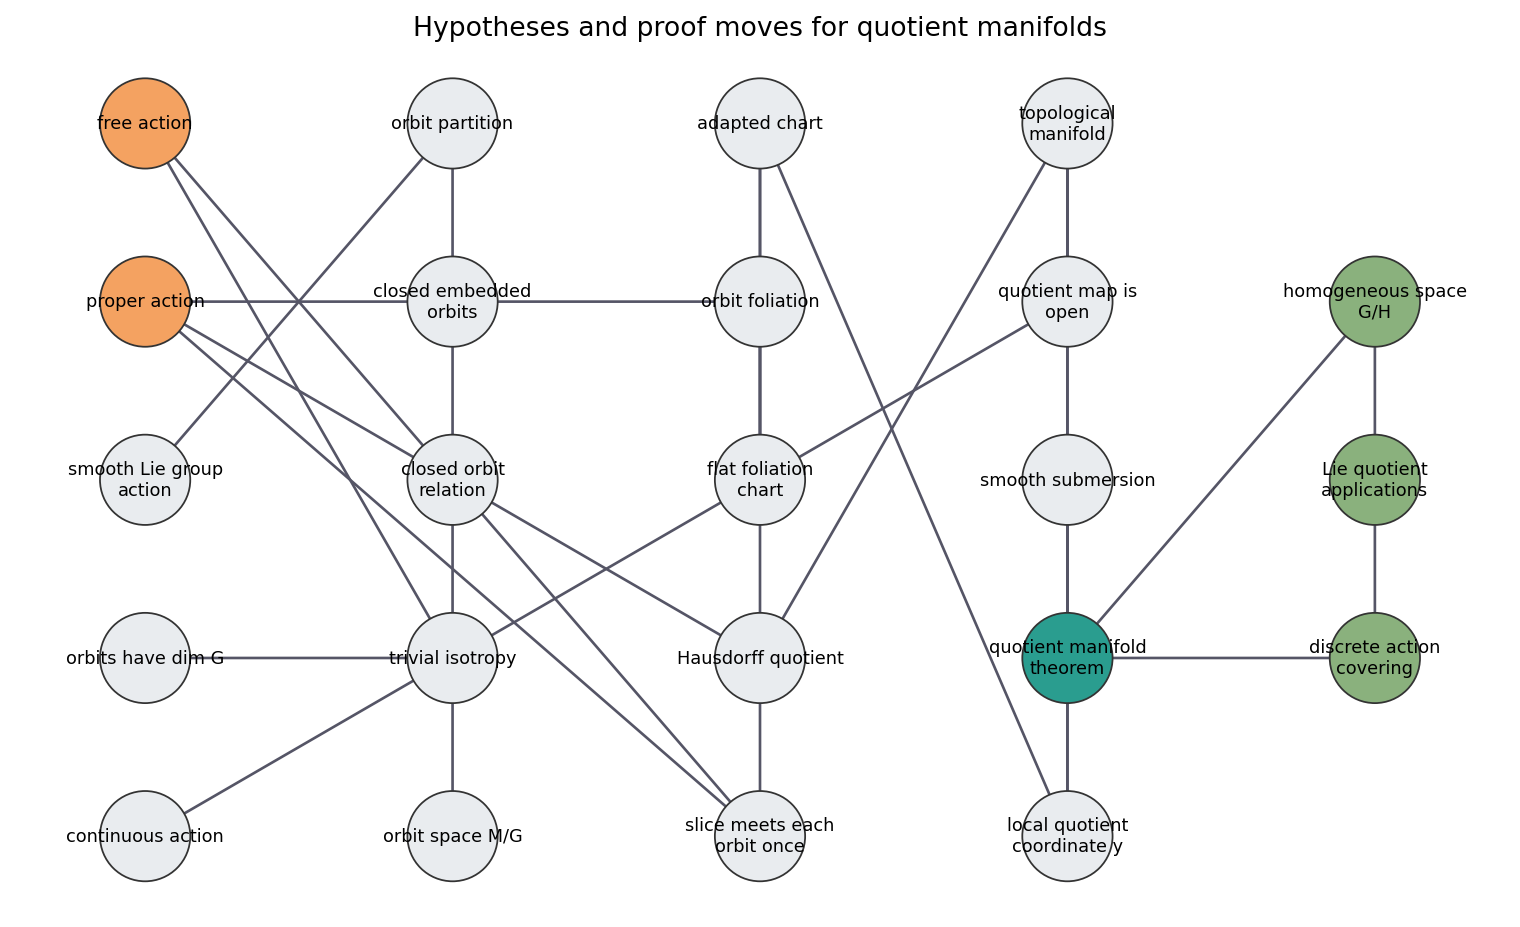

Check data: `artifacts/chapter-21-quotient-manifolds/checks/quotient-theorem-dependency-graph.json`

In [3]:
dependency_edges = [
    ("smooth Lie group action", "orbit partition"),
    ("orbit partition", "orbit space M/G"),
    ("continuous action", "quotient map is open"),
    ("proper action", "closed orbit relation"),
    ("closed orbit relation", "Hausdorff quotient"),
    ("free action", "trivial isotropy"),
    ("proper action", "closed embedded orbits"),
    ("trivial isotropy", "orbits have dim G"),
    ("closed embedded orbits", "orbit foliation"),
    ("orbit foliation", "flat foliation chart"),
    ("proper action", "slice meets each orbit once"),
    ("free action", "slice meets each orbit once"),
    ("flat foliation chart", "adapted chart"),
    ("slice meets each orbit once", "adapted chart"),
    ("adapted chart", "local quotient coordinate y"),
    ("quotient map is open", "topological manifold"),
    ("Hausdorff quotient", "topological manifold"),
    ("local quotient coordinate y", "topological manifold"),
    ("local quotient coordinate y", "smooth submersion"),
    ("topological manifold", "quotient manifold theorem"),
    ("smooth submersion", "quotient manifold theorem"),
    ("quotient manifold theorem", "discrete action covering"),
    ("quotient manifold theorem", "homogeneous space G/H"),
    ("homogeneous space G/H", "Lie quotient applications"),
    ("discrete action covering", "Lie quotient applications"),
]
G = nx.DiGraph()
G.add_edges_from(dependency_edges)

layers = {
    "input": ["continuous action", "smooth Lie group action", "free action", "proper action"],
    "orbit data": ["orbit partition", "orbit space M/G", "trivial isotropy", "closed orbit relation", "closed embedded orbits"],
    "local proof": ["Hausdorff quotient", "orbit foliation", "flat foliation chart", "slice meets each orbit once", "adapted chart"],
    "quotient": ["quotient map is open", "local quotient coordinate y", "topological manifold", "smooth submersion", "quotient manifold theorem"],
    "applications": ["discrete action covering", "homogeneous space G/H", "Lie quotient applications"],
}
layer_index = {node: i for i, nodes in enumerate(layers.values()) for node in nodes}
for node in G.nodes:
    G.nodes[node]["layer"] = layer_index.get(node, 0)

pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.3)
fig, ax = plt.subplots(figsize=(12, 7))
node_colors = []
for node in G.nodes:
    if node in {"free action", "proper action"}:
        node_colors.append("#f4a261")
    elif node == "quotient manifold theorem":
        node_colors.append("#2a9d8f")
    elif "applications" in node or node in layers["applications"]:
        node_colors.append("#8ab17d")
    else:
        node_colors.append("#e9ecef")
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=12, width=1.2, edge_color="#556")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, edgecolors="#333", node_size=1650, linewidths=0.8)
labels = {node: "\n".join(textwrap.wrap(node, 18)) for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)
ax.set_title("Hypotheses and proof moves for quotient manifolds")
ax.axis("off")
dependency_path = remember(save_matplotlib(fig, FIGURES / "quotient-theorem-dependency-graph.png"), artifact_paths)
plt.close(fig)

dependency_check = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "has_free_to_theorem_path": nx.has_path(G, "free action", "quotient manifold theorem"),
    "has_proper_to_theorem_path": nx.has_path(G, "proper action", "quotient manifold theorem"),
    "has_discrete_application_path": nx.has_path(G, "quotient manifold theorem", "discrete action covering"),
    "is_dag": nx.is_directed_acyclic_graph(G),
}
dependency_check_path = remember(save_json(dependency_check, CHECKS / "quotient-theorem-dependency-graph.json"), check_paths)
display_artifact(dependency_path, width=980)
display(Markdown(f"Check data: `{short_path(dependency_check_path)}`"))


## 2. Orbit Spaces: Good Quotients and Failure Modes

The orbit relation keeps exactly the information that is constant along orbits.
For horizontal translations of the plane, the invariant is the `y` coordinate, so
the quotient is a line. For rotations of the complex plane, the invariant is the
radius; the fixed origin becomes an endpoint-like singular class. For the full
linear action on a vector space, all nonzero vectors lie in one orbit and the origin
is another orbit; the quotient topology is too coarse to be Hausdorff.

The table records the theorem hypotheses and the visible failure mode. It is not
an abstract checklist: each failed hypothesis has a geometric symptom.


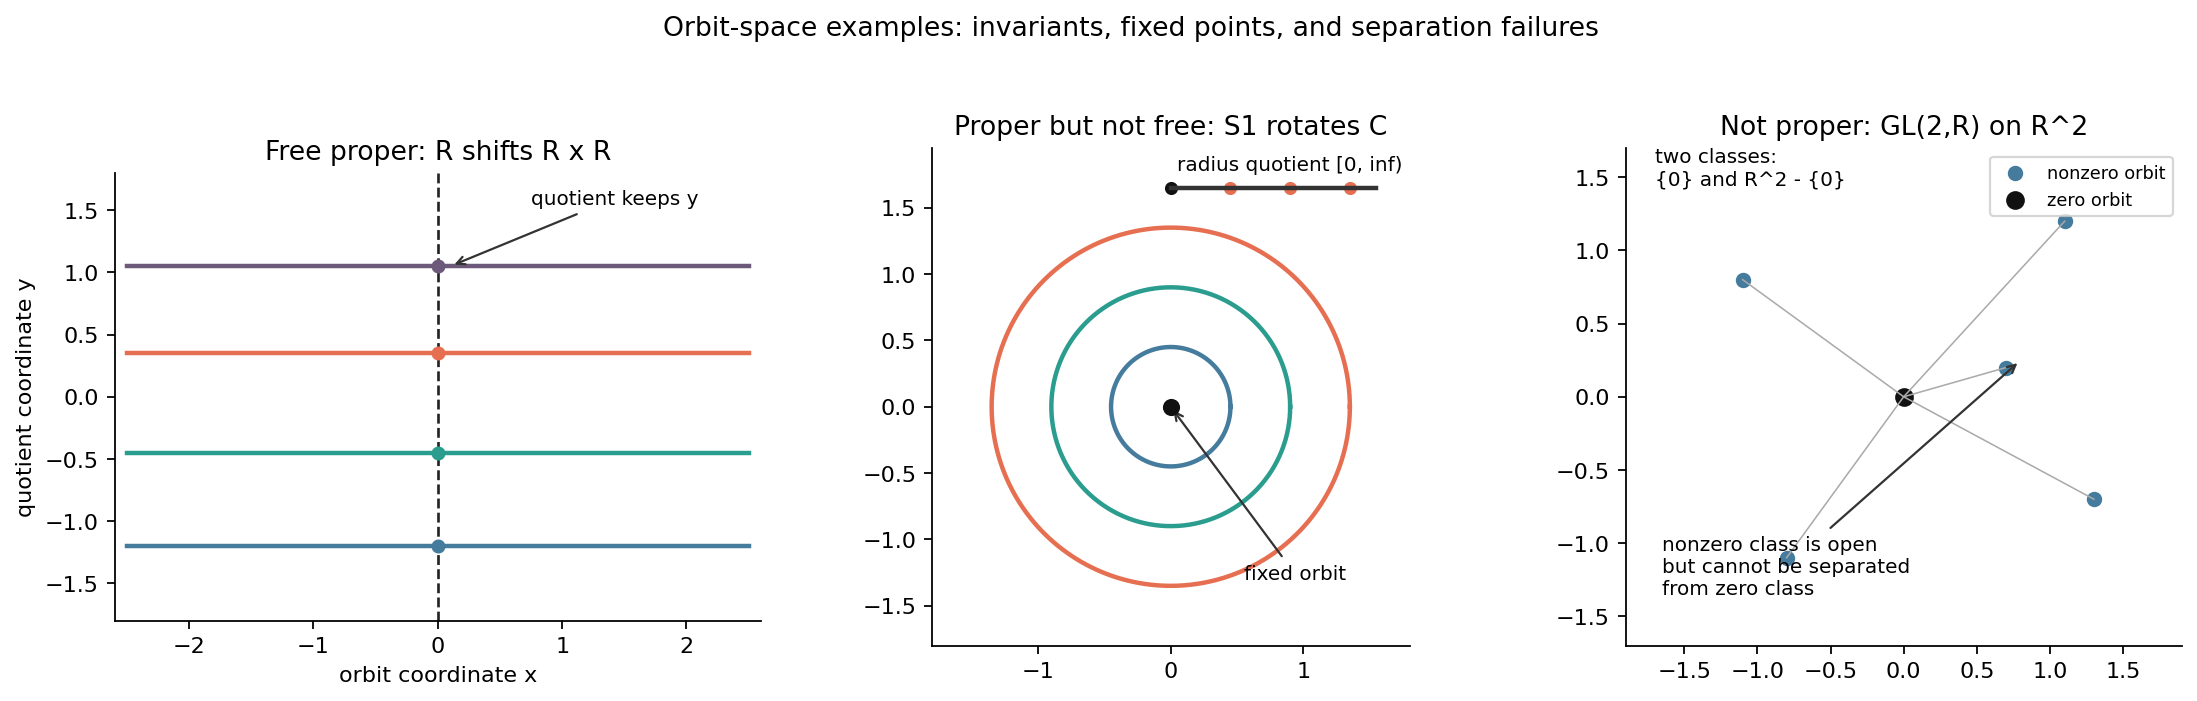

,action,orbit_invariant,free,proper,quotient,manifold,visible_symptom
0,R translates R x R horizontally,y coordinate,True,True,R,True,parallel closed orbits; projection has rank 1
1,S1 rotates C,radius,False,True,"[0, inf)",False,origin has full isotropy and becomes an endpoi...
2,"GL(2,R) acts on R^2",zero versus nonzero,False,False,two-point non-Hausdorff space,False,zero class cannot be separated from nonzero class
3,Z^2 translates R^2,coordinates modulo integers,True,True,2-torus,True,local patches lift to disjoint sheets


In [4]:
theta = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Translation action: R acts on R^2 by horizontal shifts.
ax = axes[0]
xline = np.linspace(-2.5, 2.5, 200)
for y0, color in zip([-1.2, -0.45, 0.35, 1.05], ["#457b9d", "#2a9d8f", "#e76f51", "#6d597a"]):
    ax.plot(xline, np.full_like(xline, y0), color=color, lw=2)
    ax.scatter([0], [y0], color=color, s=28, zorder=3)
ax.axvline(0, color="#222", lw=1.2, linestyle="--")
ax.annotate("quotient keeps y", xy=(0.1, 1.05), xytext=(0.75, 1.55),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)
ax.set_title("Free proper: R shifts R x R")
ax.set_xlabel("orbit coordinate x")
ax.set_ylabel("quotient coordinate y")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-1.8, 1.8)

# Rotation action: S^1 acts on C.
ax = axes[1]
for r, color in zip([0.45, 0.9, 1.35], ["#457b9d", "#2a9d8f", "#e76f51"]):
    ax.plot(r * np.cos(theta), r * np.sin(theta), color=color, lw=2)
ax.scatter([0], [0], color="#111", s=45, zorder=5)
ax.annotate("fixed orbit", xy=(0, 0), xytext=(0.55, -1.3),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)
ax.plot([0, 1.55], [1.65, 1.65], color="#333", lw=2)
for r in [0, 0.45, 0.9, 1.35]:
    ax.scatter([r], [1.65], color="#e76f51" if r else "#111", s=24)
ax.text(0.05, 1.78, "radius quotient [0, inf)", fontsize=9)
ax.set_title("Proper but not free: S1 rotates C")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.95)

# GL action on R^2: two orbit classes and non-Hausdorff quotient.
ax = axes[2]
points = np.array([[0.7, 0.2], [1.1, 1.2], [-1.1, 0.8], [-0.8, -1.1], [1.3, -0.7]])
ax.scatter(points[:, 0], points[:, 1], color="#457b9d", s=35, label="nonzero orbit")
ax.scatter([0], [0], color="#111", s=55, label="zero orbit")
for p in points:
    ax.plot([0, p[0]], [0, p[1]], color="#aaa", lw=0.7)
ax.text(-1.7, 1.45, "two classes:\n{0} and R^2 - {0}", fontsize=9)
ax.annotate("nonzero class is open\nbut cannot be separated\nfrom zero class",
            xy=(0.8, 0.25), xytext=(-1.65, -1.35),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)
ax.set_title("Not proper: GL(2,R) on R^2")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.7, 1.7)
ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Orbit-space examples: invariants, fixed points, and separation failures", y=1.03)
fig.tight_layout()
orbit_gallery_path = remember(save_matplotlib(fig, FIGURES / "orbit-space-good-bad-gallery.png"), artifact_paths)
plt.close(fig)

orbit_rows = [
    {
        "action": "R translates R x R horizontally",
        "orbit_invariant": "y coordinate",
        "free": True,
        "proper": True,
        "quotient": "R",
        "manifold": True,
        "visible_symptom": "parallel closed orbits; projection has rank 1",
    },
    {
        "action": "S1 rotates C",
        "orbit_invariant": "radius",
        "free": False,
        "proper": True,
        "quotient": "[0, inf)",
        "manifold": False,
        "visible_symptom": "origin has full isotropy and becomes an endpoint class",
    },
    {
        "action": "GL(2,R) acts on R^2",
        "orbit_invariant": "zero versus nonzero",
        "free": False,
        "proper": False,
        "quotient": "two-point non-Hausdorff space",
        "manifold": False,
        "visible_symptom": "zero class cannot be separated from nonzero class",
    },
    {
        "action": "Z^2 translates R^2",
        "orbit_invariant": "coordinates modulo integers",
        "free": True,
        "proper": True,
        "quotient": "2-torus",
        "manifold": True,
        "visible_symptom": "local patches lift to disjoint sheets",
    },
]
orbit_table_path = remember(save_csv(orbit_rows, TABLES / "orbit-space-diagnostic-table.csv"), table_paths)
orbit_check = {
    "translation_projection_rank": int(sp.Matrix([[0, 1]]).rank()),
    "rotation_origin_isotropy_dimension_proxy": 1,
    "gl2_quotient_open_sets": ["empty", "nonzero orbit class", "whole quotient"],
    "manifold_examples": [row["action"] for row in orbit_rows if row["manifold"]],
}
orbit_check_path = remember(save_json(orbit_check, CHECKS / "orbit-space-diagnostic-table.json"), check_paths)
display_artifact(orbit_gallery_path, width=980)
display(pd.DataFrame(orbit_rows))


## 3. Properness Is the Hypothesis That Stops Escaping Symmetries

Freeness only says that the stabilizer at each point is trivial. It does not say
that the quotient topology can separate orbit classes. Properness adds the missing
compactness control. In the sequence test, if `p_i` and `g_i dot p_i` both
converge, then the group elements `g_i` must have a convergent subsequence.

The dilation action on `R` shows the failure: take `p_i = 1/i` and `g_i = i`.
Both `p_i` and `g_i p_i` converge, but the group elements escape. Irrational
flow on a torus has a different symptom: the action is free, but approximate
returns occur at larger and larger times, making every orbit dense.


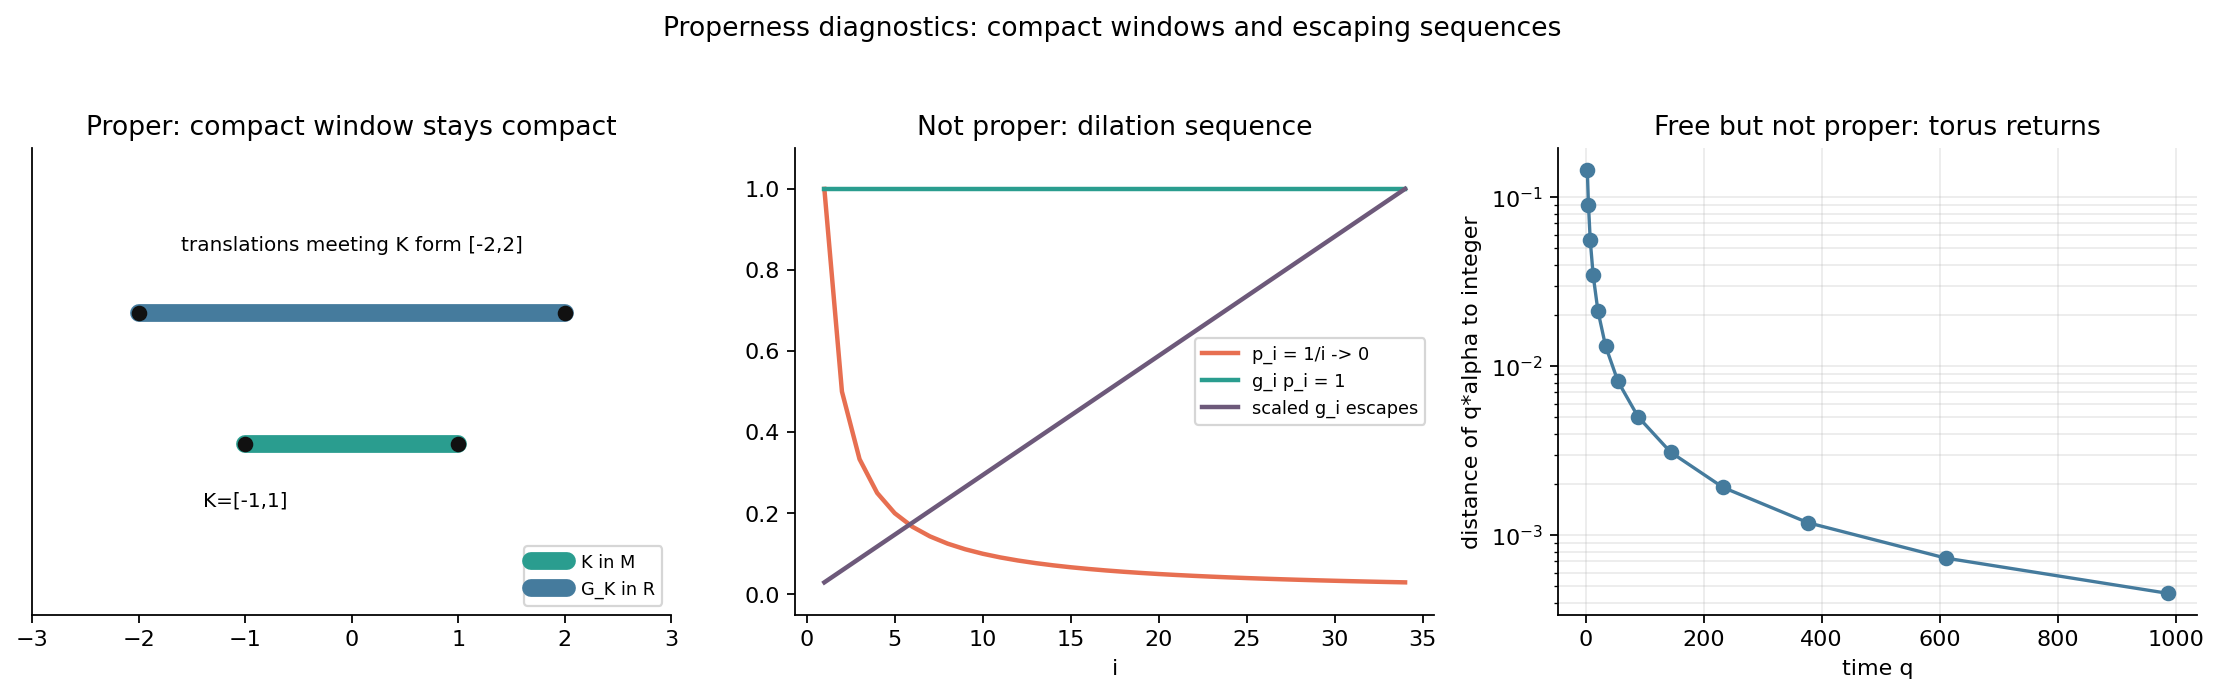

Properness check data: `artifacts/chapter-21-quotient-manifolds/checks/properness-diagnostic-tests.json`

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Compact-window test for translations.
ax = axes[0]
K = [-1, 1]
GK = [-2, 2]
ax.plot(K, [0, 0], color="#2a9d8f", lw=8, solid_capstyle="round", label="K in M")
ax.plot(GK, [0.42, 0.42], color="#457b9d", lw=8, solid_capstyle="round", label="G_K in R")
ax.scatter(K, [0, 0], color="#111", zorder=3)
ax.scatter(GK, [0.42, 0.42], color="#111", zorder=3)
ax.text(-1, -0.2, "K=[-1,1]", ha="center", fontsize=9)
ax.text(0, 0.62, "translations meeting K form [-2,2]", ha="center", fontsize=9)
ax.set_title("Proper: compact window stays compact")
ax.set_xlim(-3, 3)
ax.set_ylim(-0.55, 0.95)
ax.set_yticks([])
ax.legend(fontsize=8, loc="lower right")

# Escaping sequence for dilations.
ax = axes[1]
i = np.arange(1, 35)
p_i = 1 / i
g_i = i
image_i = g_i * p_i
ax.plot(i, p_i, color="#e76f51", lw=2, label="p_i = 1/i -> 0")
ax.plot(i, image_i, color="#2a9d8f", lw=2, label="g_i p_i = 1")
ax.plot(i, g_i / g_i.max(), color="#6d597a", lw=2, label="scaled g_i escapes")
ax.set_title("Not proper: dilation sequence")
ax.set_xlabel("i")
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8)

# Approximate returns for irrational flow.
ax = axes[2]
alpha = (math.sqrt(5) - 1) / 2
fib = [1, 2]
for _ in range(13):
    fib.append(fib[-1] + fib[-2])
denominators = np.array(fib[2:], dtype=float)
return_errors = np.abs(denominators * alpha - np.round(denominators * alpha))
ax.semilogy(denominators, return_errors, marker="o", color="#457b9d")
ax.set_title("Free but not proper: torus returns")
ax.set_xlabel("time q")
ax.set_ylabel("distance of q*alpha to integer")
ax.grid(True, which="both", alpha=0.25)

fig.suptitle("Properness diagnostics: compact windows and escaping sequences", y=1.03)
fig.tight_layout()
properness_path = remember(save_matplotlib(fig, FIGURES / "properness-diagnostic-tests.png"), artifact_paths)
plt.close(fig)

properness_report = {
    "translation_GK_interval": GK,
    "translation_GK_compact_in_R": True,
    "dilation_sequence": {
        "p_i_limit": 0.0,
        "g_i_p_i_value": 1.0,
        "g_i_last_value": int(g_i[-1]),
        "group_sequence_unbounded": bool(g_i[-1] > 30),
    },
    "irrational_alpha": alpha,
    "fibonacci_return_errors": return_errors.tolist(),
    "return_errors_decrease": bool(return_errors[-1] < return_errors[0]),
}
properness_check_path = remember(save_json(properness_report, CHECKS / "properness-diagnostic-tests.json"), check_paths)
display_artifact(properness_path, width=980)
display(Markdown(f"Properness check data: `{short_path(properness_check_path)}`"))


## 4. The Irrational Torus Flow: Free Does Not Mean Proper

Let a real parameter move around a flat torus with slope `alpha`. If `alpha` is
irrational, no nonzero time returns every coordinate exactly to its starting value,
so the action is free. The problem is topological: each orbit is dense. A quotient
whose only saturated open sets are empty and the whole space cannot be Hausdorff.

The interactive torus below traces one long orbit segment. The saved check uses
a circle-gap statistic on the return sequence to confirm that finite samples are
spreading through the torus rather than closing up.


In [6]:
alpha = (math.sqrt(5) - 1) / 2
R, r = 2.0, 0.55
u = np.linspace(0, 2 * np.pi, 70)
v = np.linspace(0, 2 * np.pi, 35)
U, V = np.meshgrid(u, v)
X = (R + r * np.cos(V)) * np.cos(U)
Y = (R + r * np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

t = np.linspace(0, 260, 2600)
theta_orbit = 2 * np.pi * (t % 1.0)
phi_orbit = 2 * np.pi * ((alpha * t) % 1.0)
xo = (R + r * np.cos(phi_orbit)) * np.cos(theta_orbit)
yo = (R + r * np.cos(phi_orbit)) * np.sin(theta_orbit)
zo = r * np.sin(phi_orbit)

torus_fig = go.Figure()
torus_fig.add_trace(go.Surface(x=X, y=Y, z=Z, opacity=0.34, showscale=False, colorscale="Greys"))
torus_fig.add_trace(go.Scatter3d(
    x=xo, y=yo, z=zo, mode="lines",
    line=dict(color="#e76f51", width=4),
    name="orbit segment"
))
torus_fig.add_trace(go.Scatter3d(
    x=[xo[0]], y=[yo[0]], z=[zo[0]], mode="markers",
    marker=dict(size=5, color="#111"),
    name="start"
))
torus_fig.update_layout(
    title="Irrational flow on T^2: a free action with dense orbits",
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, t=45, b=0),
    height=620,
)
torus_html_path = remember(save_plotly_html(torus_fig, HTML / "irrational-torus-flow-dense-orbit.html"), html_paths)

N = 987
angles = np.sort((np.arange(N) * alpha) % 1.0)
gaps = np.diff(np.r_[angles, angles[0] + 1])
torus_report = {
    "alpha": alpha,
    "sample_count": int(N),
    "max_circle_gap": float(gaps.max()),
    "mean_circle_gap": float(gaps.mean()),
    "free_action_reason": "integer time t fixes both circle coordinates only when t=0 for irrational alpha",
    "properness_symptom": "unbounded approximate return times have no convergent subsequence in R",
}
torus_check_path = remember(save_json(torus_report, CHECKS / "irrational-torus-flow-dense-orbit.json"), check_paths)
display_artifact(torus_html_path, width=900, height=640)
display(Markdown(f"Max gap among `{N}` section samples: `{gaps.max():.5f}`."))


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Max gap among `987` section samples: `0.00119`.

## 5. Adapted Charts: The Local Model of the Quotient Theorem

The theorem says that near each point of `M`, there are coordinates `(x,y)` in
which `x` runs along the group orbit and `y` is transverse. An adapted chart is
stronger than an arbitrary flat foliation chart: inside a small enough cubical
neighborhood, each orbit meets the transverse slice only once. Properness supplies
the compactness needed to shrink to that neighborhood; freeness rules out the
limiting group element fixing the base point.

Once such a chart exists, the quotient map has the coordinate form
`(x,y) -> y`, so its differential has rank `dim M - dim G`.


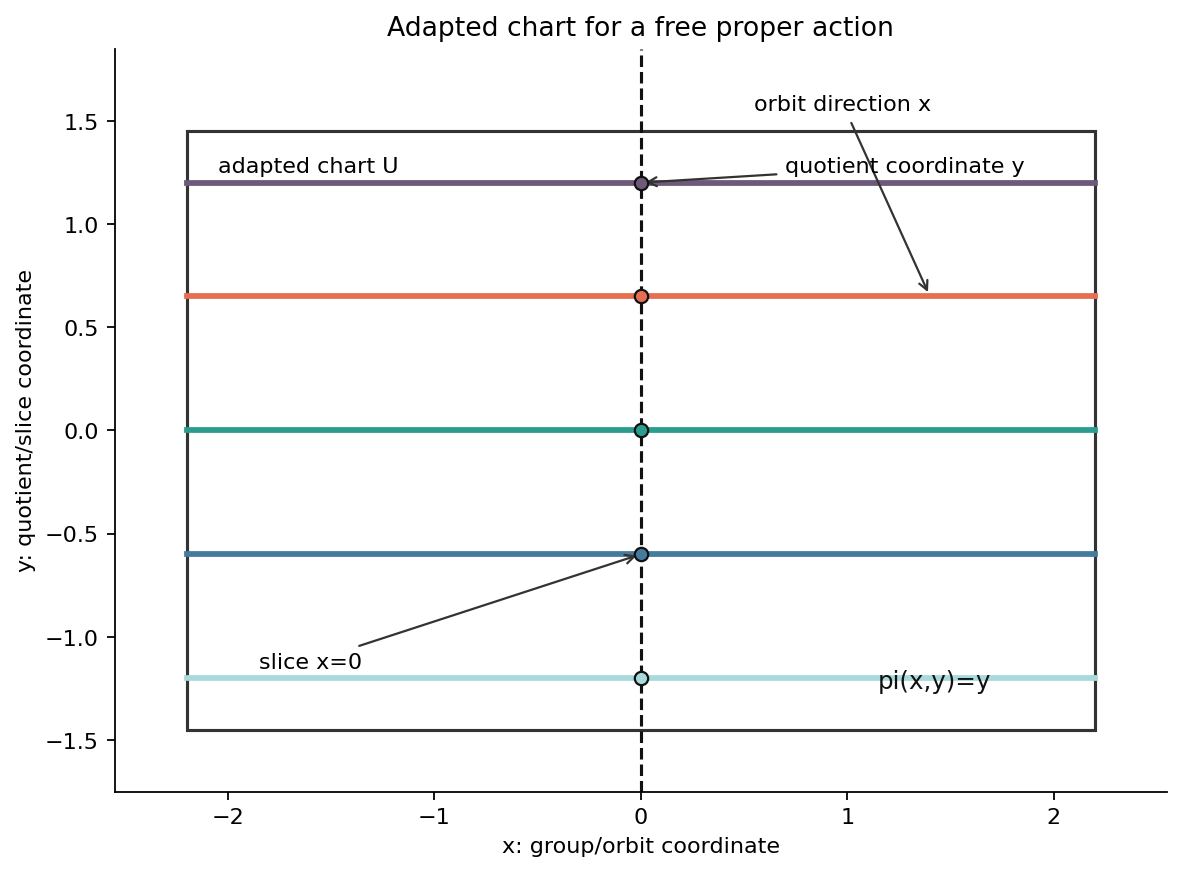

Projection rank: `1`.

In [7]:
fig, ax = plt.subplots(figsize=(8.8, 5.6))
for y0, color in zip([-1.2, -0.6, 0.0, 0.65, 1.2], ["#a8dadc", "#457b9d", "#2a9d8f", "#e76f51", "#6d597a"]):
    ax.plot([-2.2, 2.2], [y0, y0], color=color, lw=2.6)
    ax.scatter([0], [y0], color=color, edgecolor="#111", zorder=4)
ax.axvline(0, color="#111", linestyle="--", lw=1.4)
ax.add_patch(plt.Rectangle((-2.2, -1.45), 4.4, 2.9, fill=False, lw=1.4, color="#333"))
ax.annotate("orbit direction x", xy=(1.4, 0.65), xytext=(0.55, 1.55),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=10)
ax.annotate("slice x=0", xy=(0, -0.6), xytext=(-1.85, -1.15),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=10)
ax.annotate("quotient coordinate y", xy=(0, 1.2), xytext=(0.7, 1.25),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=10)
ax.text(-2.05, 1.25, "adapted chart U", fontsize=10)
ax.text(1.15, -1.25, "pi(x,y)=y", fontsize=11, color="#111")
ax.set_xlim(-2.55, 2.55)
ax.set_ylim(-1.75, 1.85)
ax.set_xlabel("x: group/orbit coordinate")
ax.set_ylabel("y: quotient/slice coordinate")
ax.set_title("Adapted chart for a free proper action")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
adapted_chart_path = remember(save_matplotlib(fig, FIGURES / "adapted-chart-quotient-local-model.png"), artifact_paths)
plt.close(fig)

x, y = sp.symbols("x y")
quotient_map = sp.Matrix([y])
jacobian = quotient_map.jacobian([x, y])
action_section = sp.Matrix([x, y])
section_jacobian = action_section.jacobian([x, y])
adapted_chart_report = {
    "model_coordinates": ["x orbit coordinate", "y quotient coordinate"],
    "quotient_map": "(x,y) -> y",
    "projection_jacobian": [[int(entry) for entry in row] for row in jacobian.tolist()],
    "projection_rank": int(jacobian.rank()),
    "expected_rank_dim_M_minus_dim_G": 1,
    "action_section_jacobian_det": int(section_jacobian.det()),
    "local_section_hits_each_displayed_orbit_once": True,
}
adapted_chart_check_path = remember(save_json(adapted_chart_report, CHECKS / "adapted-chart-quotient-local-model.json"), check_paths)
display_artifact(adapted_chart_path, width=760)
display(Markdown(f"Projection rank: `{adapted_chart_report['projection_rank']}`."))


## 6. Discrete Free Proper Actions Produce Covering Maps

For a discrete group, properness can be inspected locally: a small enough
neighborhood should not meet any of its nontrivial translates, and different
orbits should have neighborhoods that never collide under group elements. The
lattice action of `Z^2` on `R^2` is the model example. The quotient is a torus,
and the map from the plane to the torus is a normal covering map.

The picture shows one evenly covered neighborhood. Its integer translates are
the sheets over the same base patch.


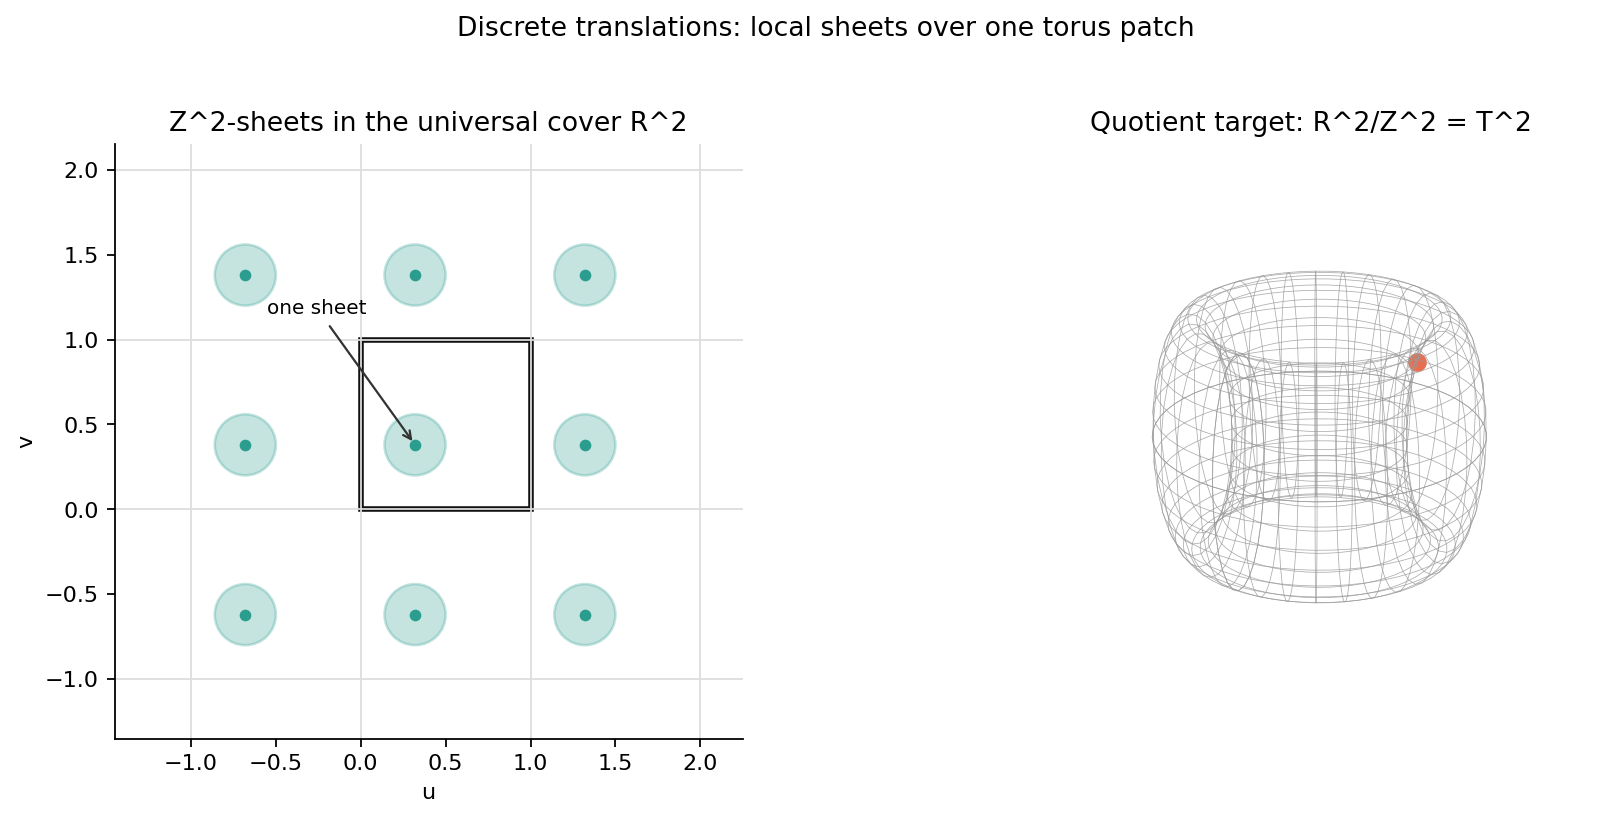

Local disjointness check: `True`.

In [8]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
for m in range(-2, 3):
    ax.axvline(m, color="#ddd", lw=0.8)
    ax.axhline(m, color="#ddd", lw=0.8)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, lw=2.5, color="#111"))
base = np.array([0.32, 0.38])
radius = 0.18
for a in range(-1, 2):
    for b in range(-1, 2):
        center = base + np.array([a, b])
        circle = plt.Circle(center, radius, color="#2a9d8f", alpha=0.27, ec="#2a9d8f", lw=1.2)
        ax.add_patch(circle)
        ax.scatter([center[0]], [center[1]], color="#2a9d8f", s=18)
ax.annotate("one sheet", xy=base, xytext=(-0.55, 1.15),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)
ax.set_title("Z^2-sheets in the universal cover R^2")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.45, 2.25)
ax.set_ylim(-1.35, 2.15)
ax.set_xlabel("u")
ax.set_ylabel("v")

ax3 = fig.add_subplot(1, 2, 2, projection="3d")
uu = np.linspace(0, 2 * np.pi, 60)
vv = np.linspace(0, 2 * np.pi, 30)
UU, VV = np.meshgrid(uu, vv)
Rt, rt = 1.35, 0.42
Xt = (Rt + rt * np.cos(VV)) * np.cos(UU)
Yt = (Rt + rt * np.cos(VV)) * np.sin(UU)
Zt = rt * np.sin(VV)
ax3.plot_wireframe(Xt, Yt, Zt, color="#999", linewidth=0.35, alpha=0.8)
patch_u = base[0] * 2 * np.pi
patch_v = base[1] * 2 * np.pi
patch_center = np.array([
    (Rt + rt * np.cos(patch_v)) * np.cos(patch_u),
    (Rt + rt * np.cos(patch_v)) * np.sin(patch_u),
    rt * np.sin(patch_v),
])
ax3.scatter([patch_center[0]], [patch_center[1]], [patch_center[2]], color="#e76f51", s=55)
ax3.set_title("Quotient target: R^2/Z^2 = T^2")
ax3.set_axis_off()
ax3.view_init(elev=23, azim=38)

fig.suptitle("Discrete translations: local sheets over one torus patch", y=1.02)
fig.tight_layout()
covering_path = remember(save_matplotlib(fig, FIGURES / "discrete-lattice-covering-torus.png"), artifact_paths)
plt.close(fig)

translations = [(a, b) for a in range(-2, 3) for b in range(-2, 3)]
nonzero_distances = [
    float(np.linalg.norm(np.array(t)))
    for t in translations
    if t != (0, 0)
]
covering_report = {
    "local_radius": radius,
    "minimum_nontrivial_translation_distance": min(nonzero_distances),
    "nontrivial_translates_of_radius_patch_are_disjoint": bool(2 * radius < min(nonzero_distances)),
    "sample_fiber_count_in_5_by_5_window": len(translations),
    "deck_group": "Z^2",
    "quotient": "2-torus",
}
covering_check_path = remember(save_json(covering_report, CHECKS / "discrete-lattice-covering-torus.json"), check_paths)
display_artifact(covering_path, width=900)
display(Markdown(f"Local disjointness check: `{covering_report['nontrivial_translates_of_radius_patch_are_disjoint']}`."))


## 7. Homogeneous Spaces Are Quotients by Isotropy

A homogeneous space is a manifold on which a Lie group acts transitively. Pick a
base point `p`. The points of the homogeneous space are exactly the cosets of the
isotropy group `G_p`: all group elements sending `p` to the same target differ by
right multiplication by an element that fixes `p`.

The standard model is `S^2 = SO(3)/SO(2)`. The map sends a rotation matrix to
the image of the north pole. Spinning a frame around the north pole changes the
rotation matrix but not its image in the quotient.


In [9]:
def sphere_xyz(phi, theta, radius=1.0):
    return (
        radius * np.sin(phi) * np.cos(theta),
        radius * np.sin(phi) * np.sin(theta),
        radius * np.cos(phi),
    )

phi_grid = np.linspace(0, np.pi, 48)
theta_grid = np.linspace(0, 2 * np.pi, 96)
Phi, Theta = np.meshgrid(phi_grid, theta_grid)
Xs, Ys, Zs = sphere_xyz(Phi, Theta)

sample_phi = np.array([0.0, 0.55, 0.95, 1.25, 1.75, 2.2])
sample_theta = np.array([0.0, 0.4, 1.8, 3.0, 4.3, 5.1])
px, py, pz = sphere_xyz(sample_phi, sample_theta)

hom_fig = go.Figure()
hom_fig.add_trace(go.Surface(x=Xs, y=Ys, z=Zs, opacity=0.35, showscale=False, colorscale="Blues", name="S^2"))
hom_fig.add_trace(go.Scatter3d(
    x=px, y=py, z=pz, mode="markers+text",
    marker=dict(size=5, color="#e76f51"),
    text=[f"A{i}e3" for i in range(len(px))],
    textposition="top center",
    name="coset representatives"
))
hom_fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[1], mode="markers+text",
    marker=dict(size=7, color="#111"),
    text=["north p"],
    textposition="bottom center",
    name="base point"
))
spin = np.linspace(0, 2 * np.pi, 160)
hom_fig.add_trace(go.Scatter3d(
    x=0.16 * np.cos(spin),
    y=0.16 * np.sin(spin),
    z=np.full_like(spin, 1.04),
    mode="lines",
    line=dict(color="#111", width=5),
    name="SO(2) isotropy spin"
))
hom_fig.update_layout(
    title="Homogeneous-space quotient: SO(3)/SO(2) is S^2",
    scene=dict(aspectmode="data"),
    height=620,
    margin=dict(l=0, r=0, t=45, b=0),
)
homogeneous_html_path = remember(save_plotly_html(hom_fig, HTML / "homogeneous-space-sphere-cosets.html"), html_paths)

def dim_so(n):
    return n * (n - 1) // 2

homogeneous_rows = [
    {"space": "S^(n-1)", "model": "SO(n)/SO(n-1)", "dimension_check": f"{dim_so(5)}-{dim_so(4)}={dim_so(5)-dim_so(4)} when n=5"},
    {"space": "R^n", "model": "E(n)/O(n)", "dimension_check": "n(n-1)/2+n - n(n-1)/2 = n"},
    {"space": "upper half-plane", "model": "SL(2,R)/SO(2)", "dimension_check": "3-1=2"},
    {"space": "real Grassmannian G_k(R^n)", "model": "GL(n,R)/block isotropy", "dimension_check": "k(n-k)"},
    {"space": "flag manifold", "model": "GL(V)/closed flag stabilizer", "dimension_check": "sum of block interaction dimensions"},
]
homogeneous_table_path = remember(save_csv(homogeneous_rows, TABLES / "homogeneous-space-models.csv"), table_paths)
dim_checks = {
    "SO_n_sphere_dimensions": {str(n): dim_so(n) - dim_so(n - 1) for n in range(2, 8)},
    "expected_sphere_dimensions": {str(n): n - 1 for n in range(2, 8)},
    "grassmannian_dim_example_G_2_R5": 2 * (5 - 2),
    "SL2_SO2_dimension": 2,
    "isotropy_SO2_fixes_north": True,
}
dim_checks["sphere_dimension_formula_matches"] = dim_checks["SO_n_sphere_dimensions"] == dim_checks["expected_sphere_dimensions"]
homogeneous_check_path = remember(save_json(dim_checks, CHECKS / "homogeneous-space-dimension-checks.json"), check_paths)
display_artifact(homogeneous_html_path, width=900, height=640)
display(pd.DataFrame(homogeneous_rows))


,space,model,dimension_check
0,S^(n-1),SO(n)/SO(n-1),10-6=4 when n=5
1,R^n,E(n)/O(n),n(n-1)/2+n - n(n-1)/2 = n
2,upper half-plane,"SL(2,R)/SO(2)",3-1=2
3,real Grassmannian G_k(R^n),"GL(n,R)/block isotropy",k(n-k)
4,flag manifold,GL(V)/closed flag stabilizer,sum of block interaction dimensions


## 8. Lie-Group Quotient Applications

Normal closed subgroups are the Lie-group version of "relations compatible with
multiplication." The quotient theorem gives `G/K` a Lie group structure when `K`
is closed and normal. A homomorphism with discrete kernel is especially rigid:
for connected groups, being surjective with discrete kernel, being a covering map,
being a local diffeomorphism, and inducing a Lie-algebra isomorphism are all the
same test in different languages.

The line-to-circle map `t -> exp(2*pi*i*t)` is the smallest example. Its kernel is
`Z`, so the quotient `R/Z` is the circle. The QR check below is a second
application from the chapter's final section: a positive-determinant matrix is
connected to an element of `SO(n)` through upper-triangular matrices with
positive diagonal.


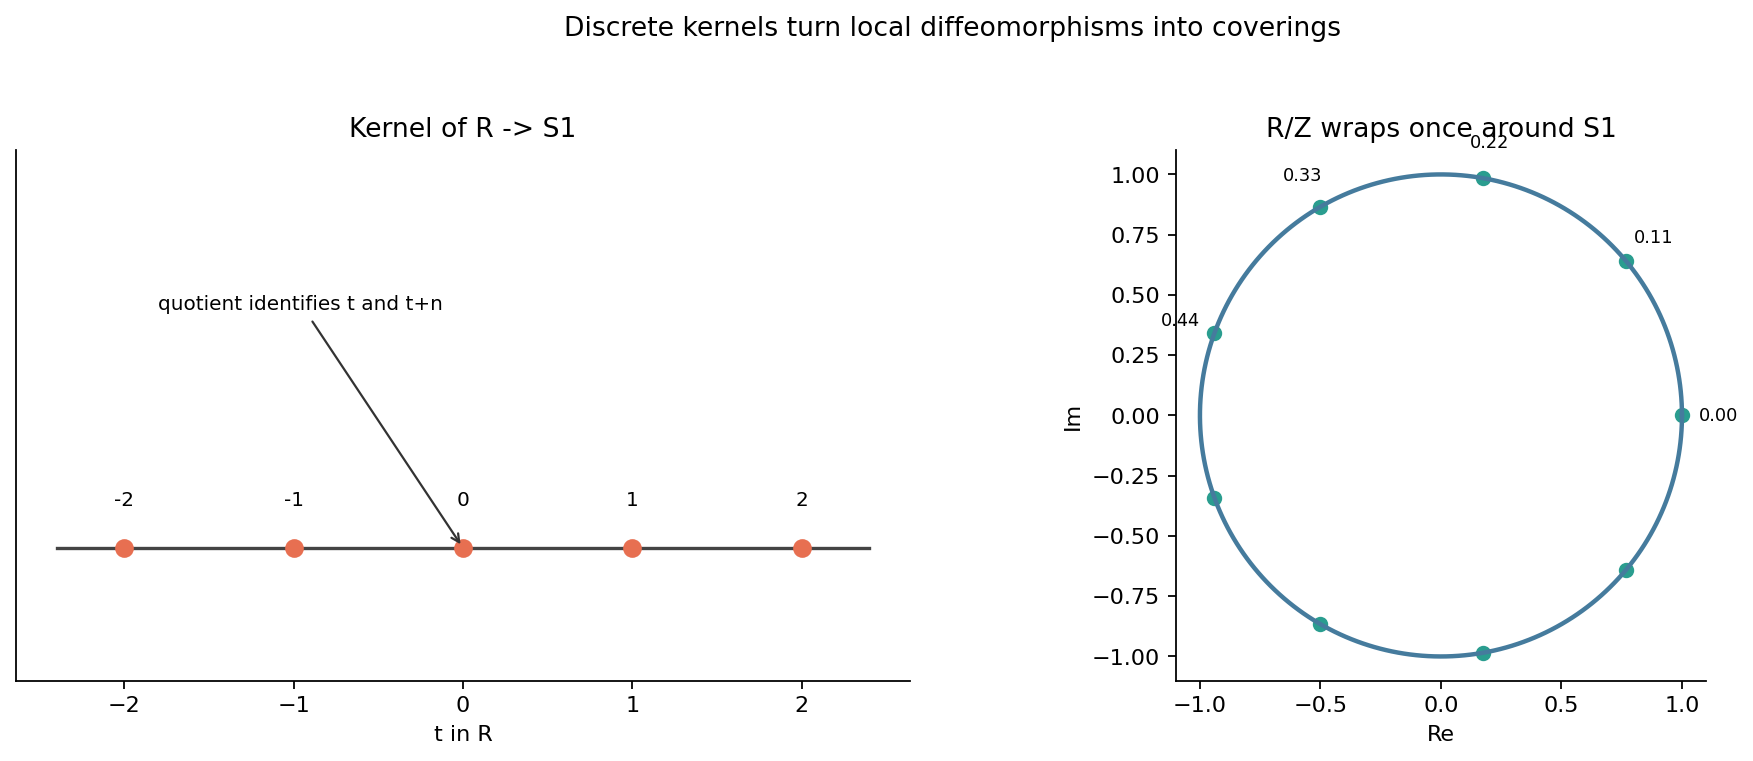

`|F(t+n)-F(t)|` max sample residual: `2.51e-15`; QR path stays in `GL+`: `True`.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
tline = np.linspace(-2.4, 2.4, 400)
ax.plot(tline, np.zeros_like(tline), color="#444", lw=1.5)
ints = np.arange(-2, 3)
ax.scatter(ints, np.zeros_like(ints), color="#e76f51", s=55, zorder=3, label="kernel Z")
for n in ints:
    ax.text(n, 0.08, str(n), ha="center", fontsize=9)
ax.annotate("quotient identifies t and t+n", xy=(0, 0), xytext=(-1.8, 0.45),
            arrowprops=dict(arrowstyle="->", color="#333"), fontsize=9)
ax.set_title("Kernel of R -> S1")
ax.set_ylim(-0.25, 0.75)
ax.set_yticks([])
ax.set_xlabel("t in R")

ax = axes[1]
circle = np.exp(2j * np.pi * np.linspace(0, 1, 500))
ax.plot(circle.real, circle.imag, color="#457b9d", lw=2)
sample_t = np.linspace(0, 1, 9, endpoint=False)
sample_z = np.exp(2j * np.pi * sample_t)
ax.scatter(sample_z.real, sample_z.imag, color="#2a9d8f", s=35)
for t0, z0 in zip(sample_t[:5], sample_z[:5]):
    ax.text(1.15 * z0.real, 1.15 * z0.imag, f"{t0:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("R/Z wraps once around S1")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Re")
ax.set_ylabel("Im")

fig.suptitle("Discrete kernels turn local diffeomorphisms into coverings", y=1.03)
fig.tight_layout()
lie_covering_path = remember(save_matplotlib(fig, FIGURES / "lie-quotient-covering-and-kernel.png"), artifact_paths)
plt.close(fig)

t_sym = sp.symbols("t", real=True)
F_real = sp.cos(2 * sp.pi * t_sym)
F_imag = sp.sin(2 * sp.pi * t_sym)
dF = sp.Matrix([sp.diff(F_real, t_sym), sp.diff(F_imag, t_sym)])
speed_squared = sp.simplify(dF.dot(dF))
residuals = []
for t0 in np.linspace(-1.75, 1.75, 15):
    for n in range(-3, 4):
        residuals.append(abs(np.exp(2j * np.pi * (t0 + n)) - np.exp(2j * np.pi * t0)))

A = np.array([[2.0, -0.8], [1.1, 1.6]])
Q, Rm = np.linalg.qr(A)
signs = np.sign(np.diag(Rm))
signs[signs == 0] = 1
S = np.diag(signs)
Q = Q @ S
Rm = S @ Rm
if np.linalg.det(Q) < 0:
    Q[:, 0] *= -1
    Rm[0, :] *= -1
ts = np.linspace(0, 1, 51)
Rt = np.array([tau * np.eye(2) + (1 - tau) * Rm for tau in ts])
det_Rt = np.linalg.det(Rt)
qr_report = {
    "matrix_A": A.tolist(),
    "det_A": float(np.linalg.det(A)),
    "det_Q": float(np.linalg.det(Q)),
    "R_diagonal": np.diag(Rm).tolist(),
    "min_det_Rt_path": float(det_Rt.min()),
    "path_stays_in_GL_plus": bool(np.all(det_Rt > 0) and np.linalg.det(A) > 0 and np.linalg.det(Q) > 0),
}
lie_report = {
    "covering_map": "t -> exp(2*pi*i*t)",
    "kernel_sample": ints.tolist(),
    "invariance_max_residual_F_t_plus_n_minus_F_t": float(max(residuals)),
    "speed_squared_symbolic": str(speed_squared),
    "speed_nonzero": bool(speed_squared != 0),
    "qr_connectivity_check": qr_report,
}
lie_check_path = remember(save_json(lie_report, CHECKS / "lie-quotient-covering-and-kernel.json"), check_paths)
display_artifact(lie_covering_path, width=860)
display(Markdown(f"`|F(t+n)-F(t)|` max sample residual: `{max(residuals):.2e}`; QR path stays in `GL+`: `{qr_report['path_stays_in_GL_plus']}`."))


## Applied Lab: Diagnose a Candidate Quotient

Use the matrix below as a compact checklist. A "yes" in the final column does not
replace a proof, but it tells you that the quotient manifold theorem is the right
tool. A failed entry points to the kind of pathology the chapter warns about:
fixed points, nonclosed orbits, escaping group elements, or non-Hausdorff orbit
relations.


In [11]:
lab_rows = [
    {
        "candidate": "R acts on R x R by horizontal translation",
        "smooth": True,
        "free": True,
        "proper": True,
        "expected_quotient": "R",
        "theorem_applies": True,
        "dimension": "2-1=1",
    },
    {
        "candidate": "S1 acts on C by rotation",
        "smooth": True,
        "free": False,
        "proper": True,
        "expected_quotient": "radius half-line",
        "theorem_applies": False,
        "dimension": "fixed origin violates freeness",
    },
    {
        "candidate": "R acts on T2 with irrational slope",
        "smooth": True,
        "free": True,
        "proper": False,
        "expected_quotient": "trivial/non-Hausdorff topology",
        "theorem_applies": False,
        "dimension": "dense orbits violate properness",
    },
    {
        "candidate": "Z^2 acts on R^2 by translations",
        "smooth": True,
        "free": True,
        "proper": True,
        "expected_quotient": "T2",
        "theorem_applies": True,
        "dimension": "2-0=2",
    },
    {
        "candidate": "closed H acts on G by right translation",
        "smooth": True,
        "free": True,
        "proper": True,
        "expected_quotient": "G/H homogeneous space",
        "theorem_applies": True,
        "dimension": "dim G - dim H",
    },
]
lab_table_path = remember(save_csv(lab_rows, TABLES / "quotient-action-lab-diagnostics.csv"), table_paths)
lab_report = {
    "candidate_count": len(lab_rows),
    "theorem_applies_count": sum(row["theorem_applies"] for row in lab_rows),
    "failed_freeness_cases": [row["candidate"] for row in lab_rows if not row["free"]],
    "failed_properness_cases": [row["candidate"] for row in lab_rows if not row["proper"]],
}
lab_check_path = remember(save_json(lab_report, CHECKS / "quotient-action-lab-diagnostics.json"), check_paths)
display(pd.DataFrame(lab_rows))


,candidate,smooth,free,proper,expected_quotient,theorem_applies,dimension
0,R acts on R x R by horizontal translation,True,True,True,R,True,2-1=1
1,S1 acts on C by rotation,True,False,True,radius half-line,False,fixed origin violates freeness
2,R acts on T2 with irrational slope,True,True,False,trivial/non-Hausdorff topology,False,dense orbits violate properness
3,Z^2 acts on R^2 by translations,True,True,True,T2,True,2-0=2
4,closed H acts on G by right translation,True,True,True,G/H homogeneous space,True,dim G - dim H


## Final Sanity Checks

The final cell checks both file integrity and mathematical invariants:

- generated PNG, HTML, CSV, and JSON artifacts exist and are nonempty;
- the proof graph contains paths from freeness and properness to the theorem;
- the adapted quotient chart has projection rank `dim M - dim G`;
- the lattice covering patch is disjoint from all nontrivial nearby translates;
- the irrational torus sample has small gaps rather than a closed finite orbit;
- the homogeneous-space dimension formula matches `SO(n)/SO(n-1) = S^(n-1)`;
- the line-to-circle map is invariant under integer shifts and has nonzero speed.


In [12]:
# final_sanity
all_paths = artifact_paths + html_paths + check_paths + table_paths
assert_artifacts(all_paths, min_bytes=64)

assert dependency_check["has_free_to_theorem_path"]
assert dependency_check["has_proper_to_theorem_path"]
assert dependency_check["is_dag"]
assert orbit_check["translation_projection_rank"] == 1
assert properness_report["dilation_sequence"]["group_sequence_unbounded"]
assert properness_report["return_errors_decrease"]
assert torus_report["max_circle_gap"] < 0.01
assert adapted_chart_report["projection_rank"] == adapted_chart_report["expected_rank_dim_M_minus_dim_G"]
assert covering_report["nontrivial_translates_of_radius_patch_are_disjoint"]
assert dim_checks["sphere_dimension_formula_matches"]
assert lie_report["invariance_max_residual_F_t_plus_n_minus_F_t"] < 1e-12
assert lie_report["speed_nonzero"]
assert lie_report["qr_connectivity_check"]["path_stays_in_GL_plus"]

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 540-563; pdftotext extraction window 558-581",
    "artifact_count": len(artifact_paths),
    "html_count": len(html_paths),
    "check_count": len(check_paths),
    "table_count": len(table_paths),
    "core_assertions": {
        "free_and_proper_feed_theorem": True,
        "adapted_chart_projection_rank": adapted_chart_report["projection_rank"],
        "covering_patch_disjoint": covering_report["nontrivial_translates_of_radius_patch_are_disjoint"],
        "torus_flow_max_gap": torus_report["max_circle_gap"],
        "homogeneous_dimension_formula": dim_checks["sphere_dimension_formula_matches"],
        "integer_kernel_residual": lie_report["invariance_max_residual_F_t_plus_n_minus_F_t"],
        "qr_path_stays_positive_determinant": lie_report["qr_connectivity_check"]["path_stays_in_GL_plus"],
    },
    "artifacts": [short_path(path) for path in artifact_paths],
    "html": [short_path(path) for path in html_paths],
    "checks": [short_path(path) for path in check_paths],
    "tables": [short_path(path) for path in table_paths],
}
final_sanity_path = remember(save_json(final_sanity, CHECKS / "final_sanity.json"), check_paths)
assert_artifacts([final_sanity_path], min_bytes=256)
display(Markdown(f"Final sanity report written to `{short_path(final_sanity_path)}`."))


Final sanity report written to `artifacts/chapter-21-quotient-manifolds/checks/final_sanity.json`.

## Takeaways

- The quotient map for an action is always open, but a useful smooth quotient
needs more than openness.
- Freeness controls isotropy; properness controls topology. Together they make
orbits embedded leaves and allow adapted charts.
- In adapted coordinates, the quotient theorem becomes the familiar submersion
model `(x,y) -> y`.
- Discrete free proper actions turn quotient maps into normal covering maps.
- Homogeneous spaces are exactly transitive smooth actions viewed as coset
spaces `G/G_p`.
- Lie-theory applications reuse the same mechanism: closed normal subgroups
give quotient Lie groups, discrete kernels give coverings, and homogeneous
quotients explain connectedness results for matrix groups.
